# ElderGuard Analytics – Exploratory Data Analysis
### Predicting Activity Levels of Elderly Residents from Smart Home Sensor Data

**Objective:** Understand the structure, quality, and patterns of the `gas_monitoring` dataset to inform model design and feature engineering decisions for predicting resident *Activity Level* (`Low Activity`, `Moderate Activity`, `High Activity`).

---
## EDA Roadmap
1. Data Loading & Structure
2. Data Quality Assessment (missing values, duplicates, outliers)
3. Target Variable Analysis
4. Univariate Analysis (numeric & categorical features)
5. Bivariate Analysis (features vs. target)
6. Correlation Analysis
7. Engineered Feature Preview
8. Summary of Key Findings

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DB_PATH = 'data/gas_monitoring.db'

conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql('SELECT * FROM gas_monitoring', conn)
conn.close()

print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Loaded: 10,000 rows × 14 columns


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


## 1. Data Structure
**Purpose:** Understand column types and spot immediate issues such as wrong dtypes or all-null columns.

In [2]:
print('Column dtypes:')
print(df_raw.dtypes)
print('\nShape:', df_raw.shape)

Column dtypes:
Time of Day                      str
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode              str
Ambient Light Level              str
Activity Level                   str
dtype: object

Shape: (10000, 14)


**Conclusion:** All sensor readings are stored as `REAL` (float64), the three categorical fields (`Time of Day`, `HVAC Operation Mode`, `Ambient Light Level`) and the target (`Activity Level`) are `TEXT`. Session ID is an integer identifier.

## 2. Data Quality Assessment
**Purpose:** Identify and quantify missing values, duplicate rows, class-label variants, and anomalous sensor readings that need to be addressed before modelling.

Columns with missing values:


,Missing Count,Missing %
Humidity,1928,19.28
MetalOxideSensor_Unit2,1410,14.10
Ambient Light Level,1054,10.54
CO_GasSensor,834,8.34


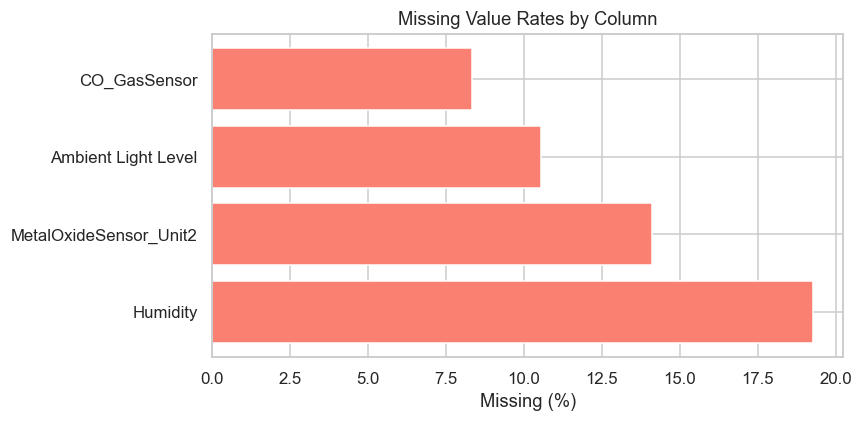

In [3]:
# --- Missing values ---
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values:')
display(miss_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(miss_df.index, miss_df['Missing %'], color='salmon')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Rates by Column')
plt.tight_layout()
plt.show()

**Conclusion:** Four columns have missing data: `Humidity` (~19%), `MetalOxideSensor_Unit2` (~14%), `Ambient Light Level` (~10.5%), and `CO_GasSensor` (~8.3%). Missing values likely represent sensor dropouts or communication failures rather than structural absence. We will **impute numerics with the column median** (robust to outliers) and **impute `Ambient Light Level` with the mode**, both computed on the training split only to prevent leakage.

In [4]:
# --- Duplicate rows ---
dupes = df_raw.duplicated().sum()
print(f'Duplicate rows: {dupes}')

# --- Activity Level variants ---
print('\nRaw Activity Level values:')
print(df_raw['Activity Level'].value_counts())

# --- HVAC Operation Mode variants ---
print('\nRaw HVAC Operation Mode values:')
print(df_raw['HVAC Operation Mode'].value_counts())

Duplicate rows: 171

Raw Activity Level values:
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

Raw HVAC Operation Mode values:
HVAC Operation Mode
cooling_active      1502
maintenance_mode    1500
heating_active      1468
off                 1456
eco_mode            1452
ventilation_only    1394
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     106
Off                  103
HEATING_ACTIVE        98
VENTILATION_ONLY      98
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64


**Conclusion:** 
- No duplicate rows.
- `Activity Level` has 6 raw values but only 3 semantic classes (`Low Activity`, `Moderate Activity`, `High Activity`). The variants (`Low_Activity`, `LowActivity`, `ModerateActivity`) are normalised by lower-casing and mapping to canonical labels.
- `HVAC Operation Mode` similarly has mixed-case duplicates that are standardised to lower-case.

Temperature statistics:
count    10000.000000
mean        42.243124
std         73.974956
min          6.903485
25%         18.937500
50%         20.510000
75%         23.172500
max        307.070000
Name: Temperature, dtype: float64


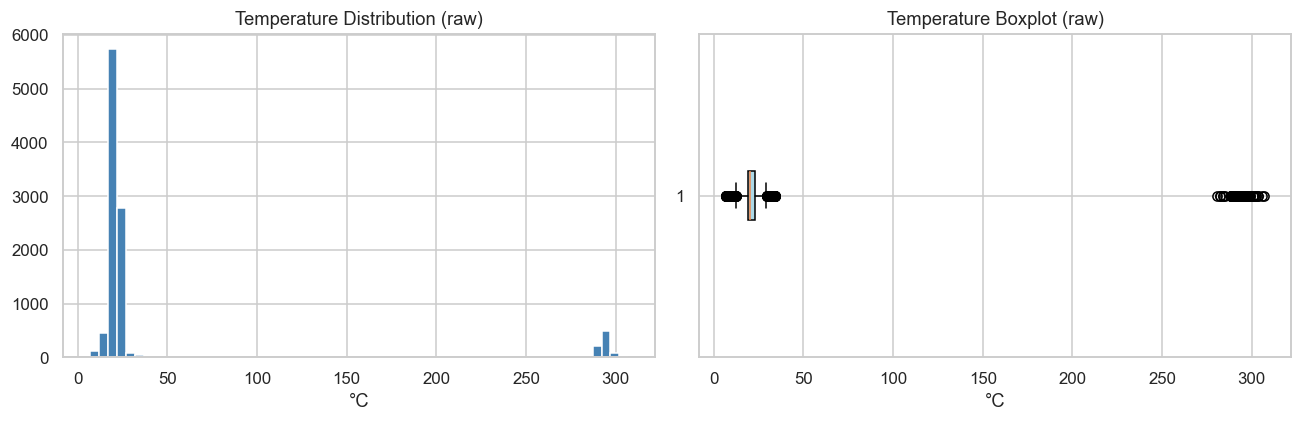


IQR fence upper bound: 29.52 °C
Temperature outliers above fence: 870 (8.7%)


In [5]:
# --- Temperature outlier investigation ---
print('Temperature statistics:')
print(df_raw['Temperature'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw['Temperature'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Temperature Distribution (raw)')
axes[0].set_xlabel('°C')

axes[1].boxplot(df_raw['Temperature'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Temperature Boxplot (raw)')
axes[1].set_xlabel('°C')
plt.tight_layout()
plt.show()

q1, q3 = df_raw['Temperature'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outlier_count = (df_raw['Temperature'] > upper_fence).sum()
print(f'\nIQR fence upper bound: {upper_fence:.2f} °C')
print(f'Temperature outliers above fence: {outlier_count} ({outlier_count/len(df_raw)*100:.1f}%)')

**Conclusion:** The median temperature is ~20.5 °C (normal indoor range) but the maximum is 307 °C — physically impossible for a residential indoor sensor. 870 values (8.7%) exceed the IQR upper fence of ~29.5 °C. These are treated as **synthetic contamination or sensor faults** and capped at the upper fence value rather than dropped, preserving the sample while removing the distorting effect on model training.

## 3. Target Variable Analysis
**Purpose:** Understand class balance which directly affects model selection, metric choice, and potential need for resampling.

Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095
Name: count, dtype: int64


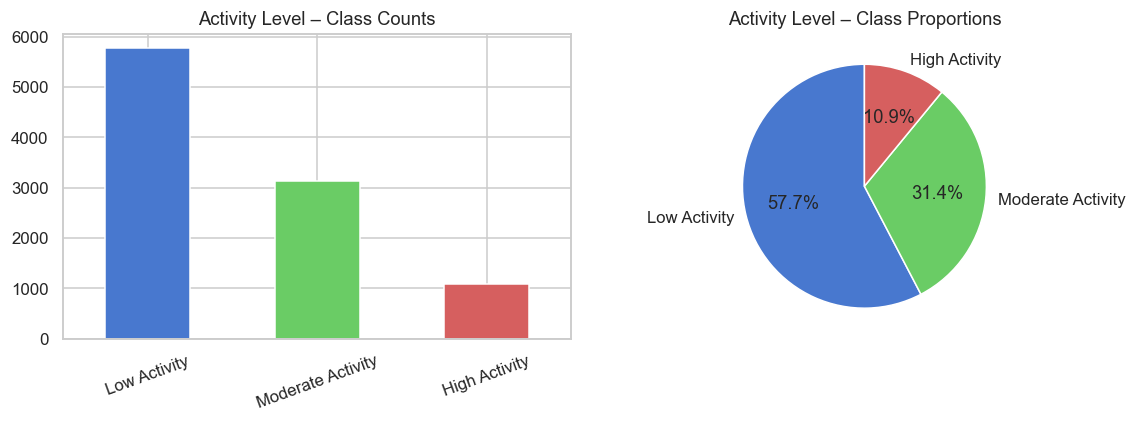

In [6]:
# Normalise labels for analysis
label_map = {
    'low activity': 'Low Activity', 'low_activity': 'Low Activity', 'lowactivity': 'Low Activity',
    'moderate activity': 'Moderate Activity', 'moderateactivity': 'Moderate Activity',
    'high activity': 'High Activity',
}
df = df_raw.copy()
df['Activity Level'] = df['Activity Level'].str.strip().str.lower().map(label_map)

class_counts = df['Activity Level'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['#4878CF', '#6ACC65', '#D65F5F'], edgecolor='white')
axes[0].set_title('Activity Level – Class Counts')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#4878CF', '#6ACC65', '#D65F5F'], startangle=90)
axes[1].set_title('Activity Level – Class Proportions')
plt.tight_layout()
plt.show()

**Conclusion:** The dataset is **moderately imbalanced**: Low Activity ~57.7%, Moderate Activity ~31.4%, High Activity ~10.9%. A model that predicts 'Low Activity' for everything would achieve ~58% accuracy. This motivates using **macro-averaged F1** as the primary evaluation metric, which weights each class equally and is more informative for the elder-care use case where missing a High Activity episode is clinically significant.

## 4. Univariate Analysis
**Purpose:** Understand the distribution and spread of each numeric feature to identify skewness, normality, and range issues.

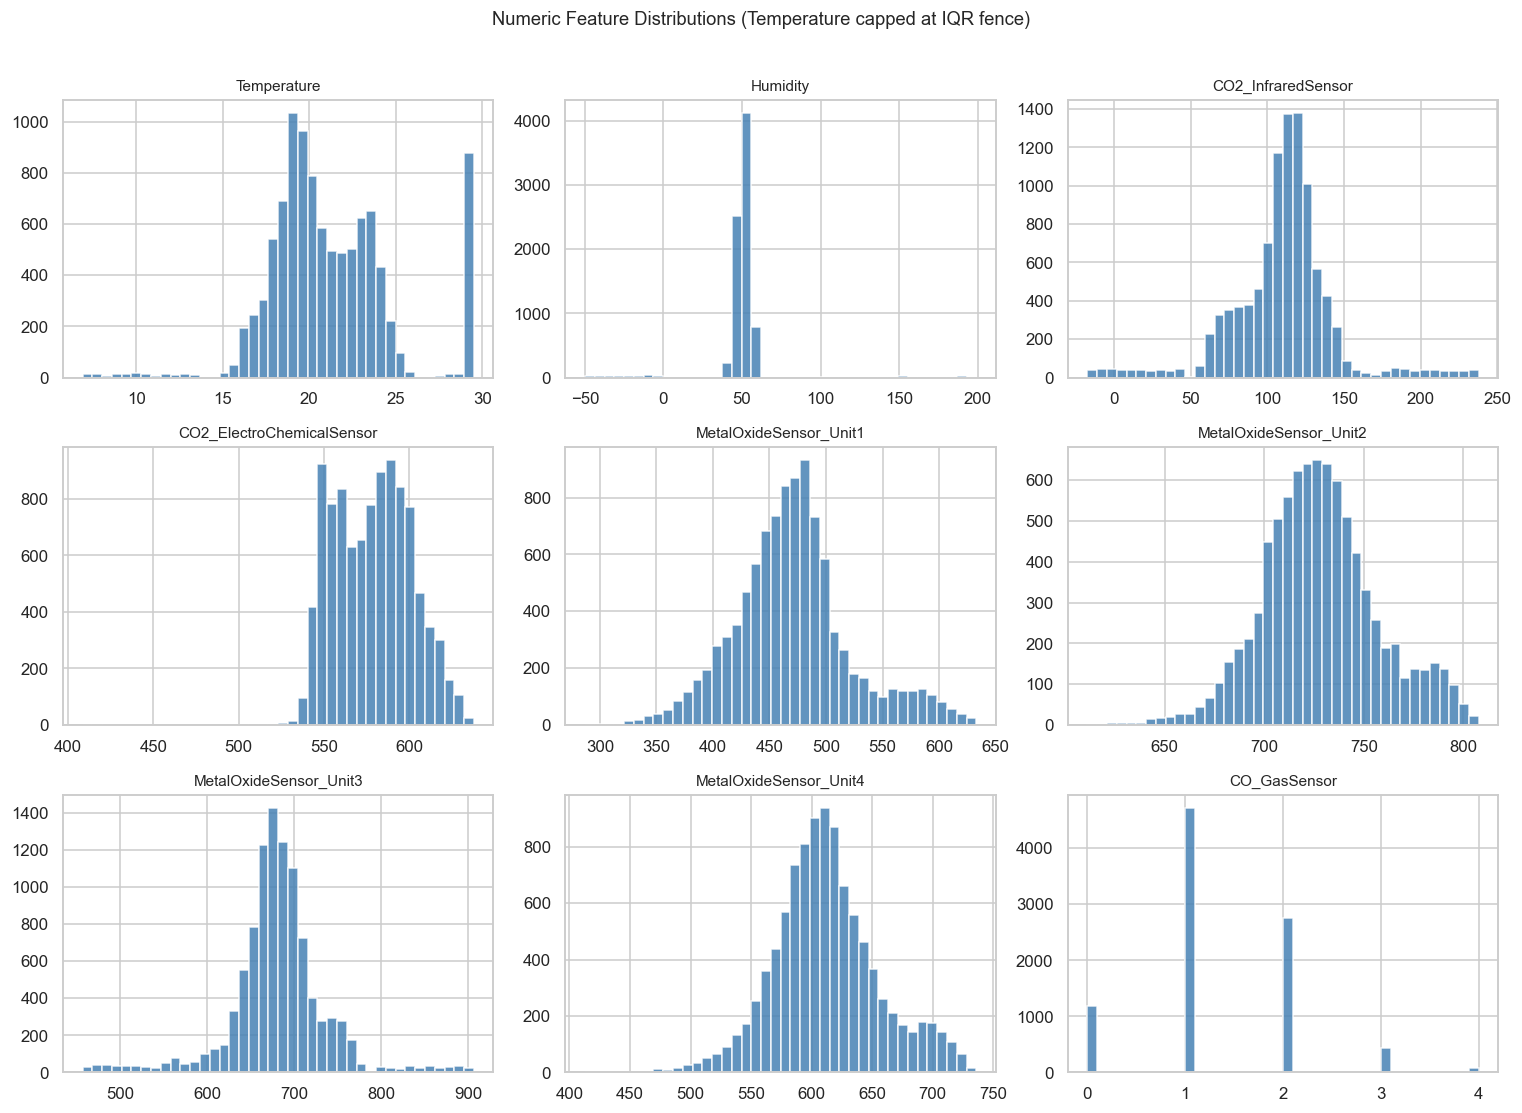

       Temperature  Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  \
count     10000.00   8072.00            10000.00                   10000.00   
mean         21.22     51.64              109.86                     578.63   
std           3.62     21.33               33.79                      22.57   
min           6.90    -49.87              -17.47                     408.60   
25%          18.94     47.66               96.66                     559.35   
50%          20.51     51.39              112.81                     579.36   
75%          23.17     53.84              124.54                     595.57   
max          29.52    198.90              237.87                     637.90   

       MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  \
count                10000.00                 8590.00                10000.00   
mean                   470.93                  728.35                  680.49   
std                     51.46                

In [7]:
numeric_cols = ['Temperature', 'Humidity', 'CO2_InfraredSensor',
                'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1',
                'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3',
                'MetalOxideSensor_Unit4', 'CO_GasSensor']

# Cap Temperature for the rest of the EDA
q3_temp = df['Temperature'].quantile(0.75)
iqr_temp = q3_temp - df['Temperature'].quantile(0.25)
df['Temperature'] = df['Temperature'].clip(upper=q3_temp + 1.5 * iqr_temp)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Numeric Feature Distributions (Temperature capped at IQR fence)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(df[numeric_cols].describe().round(2))

**Conclusion:** After capping, Temperature follows a reasonable indoor distribution (~18–29 °C). Humidity and Gas sensors appear approximately normally distributed or slightly skewed. The four Metal Oxide sensors have similar ranges, suggesting they sample the same space. CO2 sensors also track closely. CO_GasSensor has a tighter distribution centred near typical background levels.

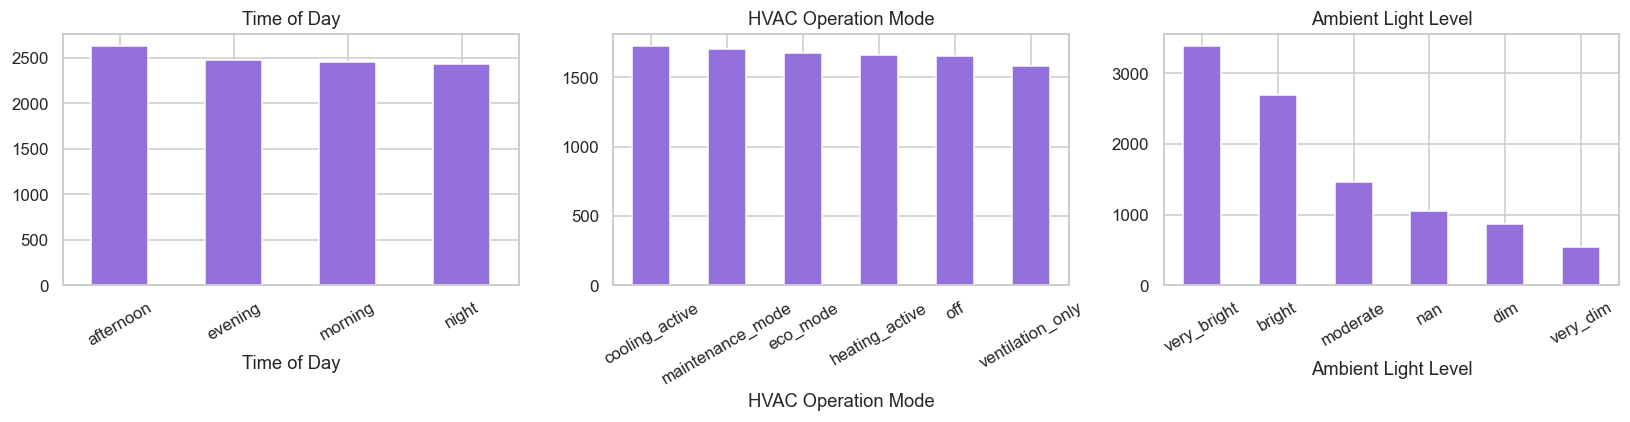

In [8]:
# Categorical feature distributions
cat_cols = ['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level']
# Normalise HVAC casing
df['HVAC Operation Mode'] = df['HVAC Operation Mode'].str.strip().str.lower()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts(dropna=False)
    vc.plot(kind='bar', ax=ax, edgecolor='white', color='mediumpurple')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Conclusion:** Time of Day is roughly balanced across four periods. HVAC modes are broadly balanced across 6 modes after normalising case variants. Ambient Light Level skews toward brighter values (`very_bright` most frequent), consistent with daytime-heavy activity capture.

## 5. Bivariate Analysis – Features vs Target
**Purpose:** Identify which features show the clearest separation across activity classes. These are the most promising predictors.

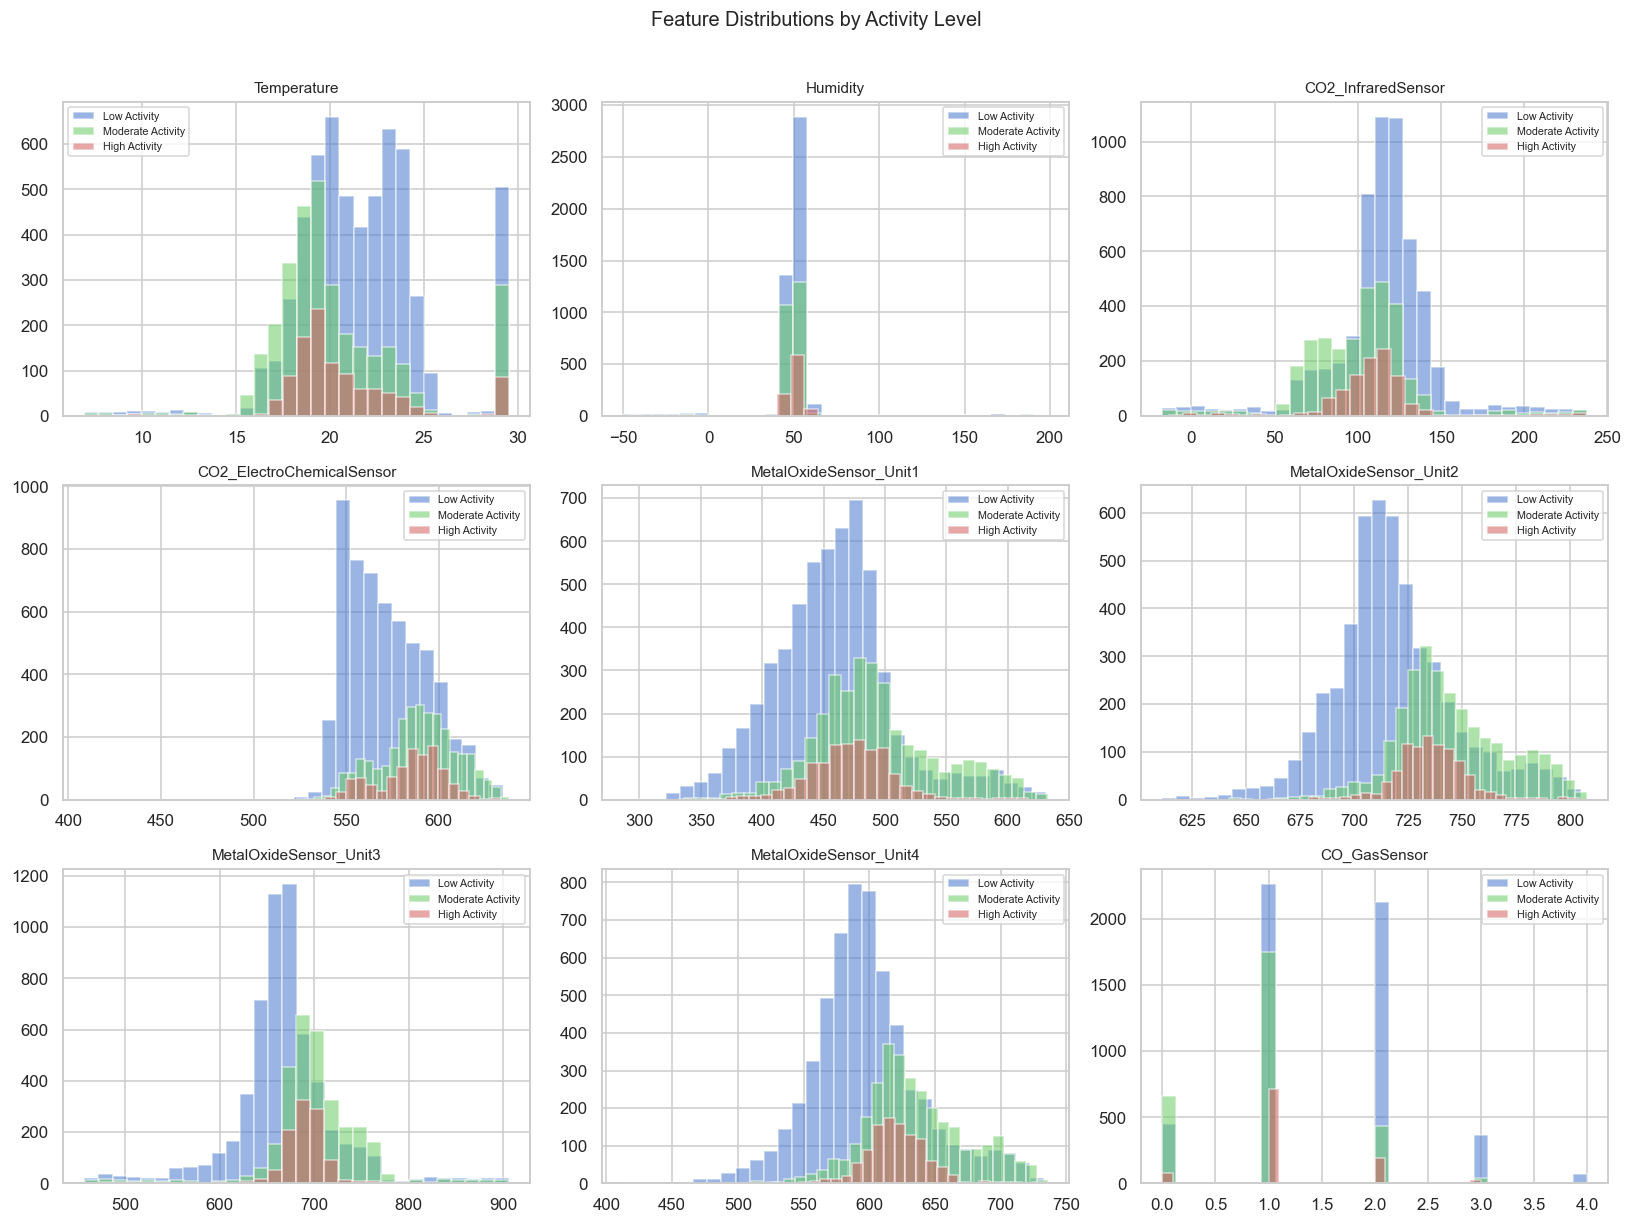

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
palette = {'Low Activity': '#4878CF', 'Moderate Activity': '#6ACC65', 'High Activity': '#D65F5F'}

for i, col in enumerate(numeric_cols):
    for label, color in palette.items():
        subset = df[df['Activity Level'] == label][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.55, label=label, color=color, edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Activity Level', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

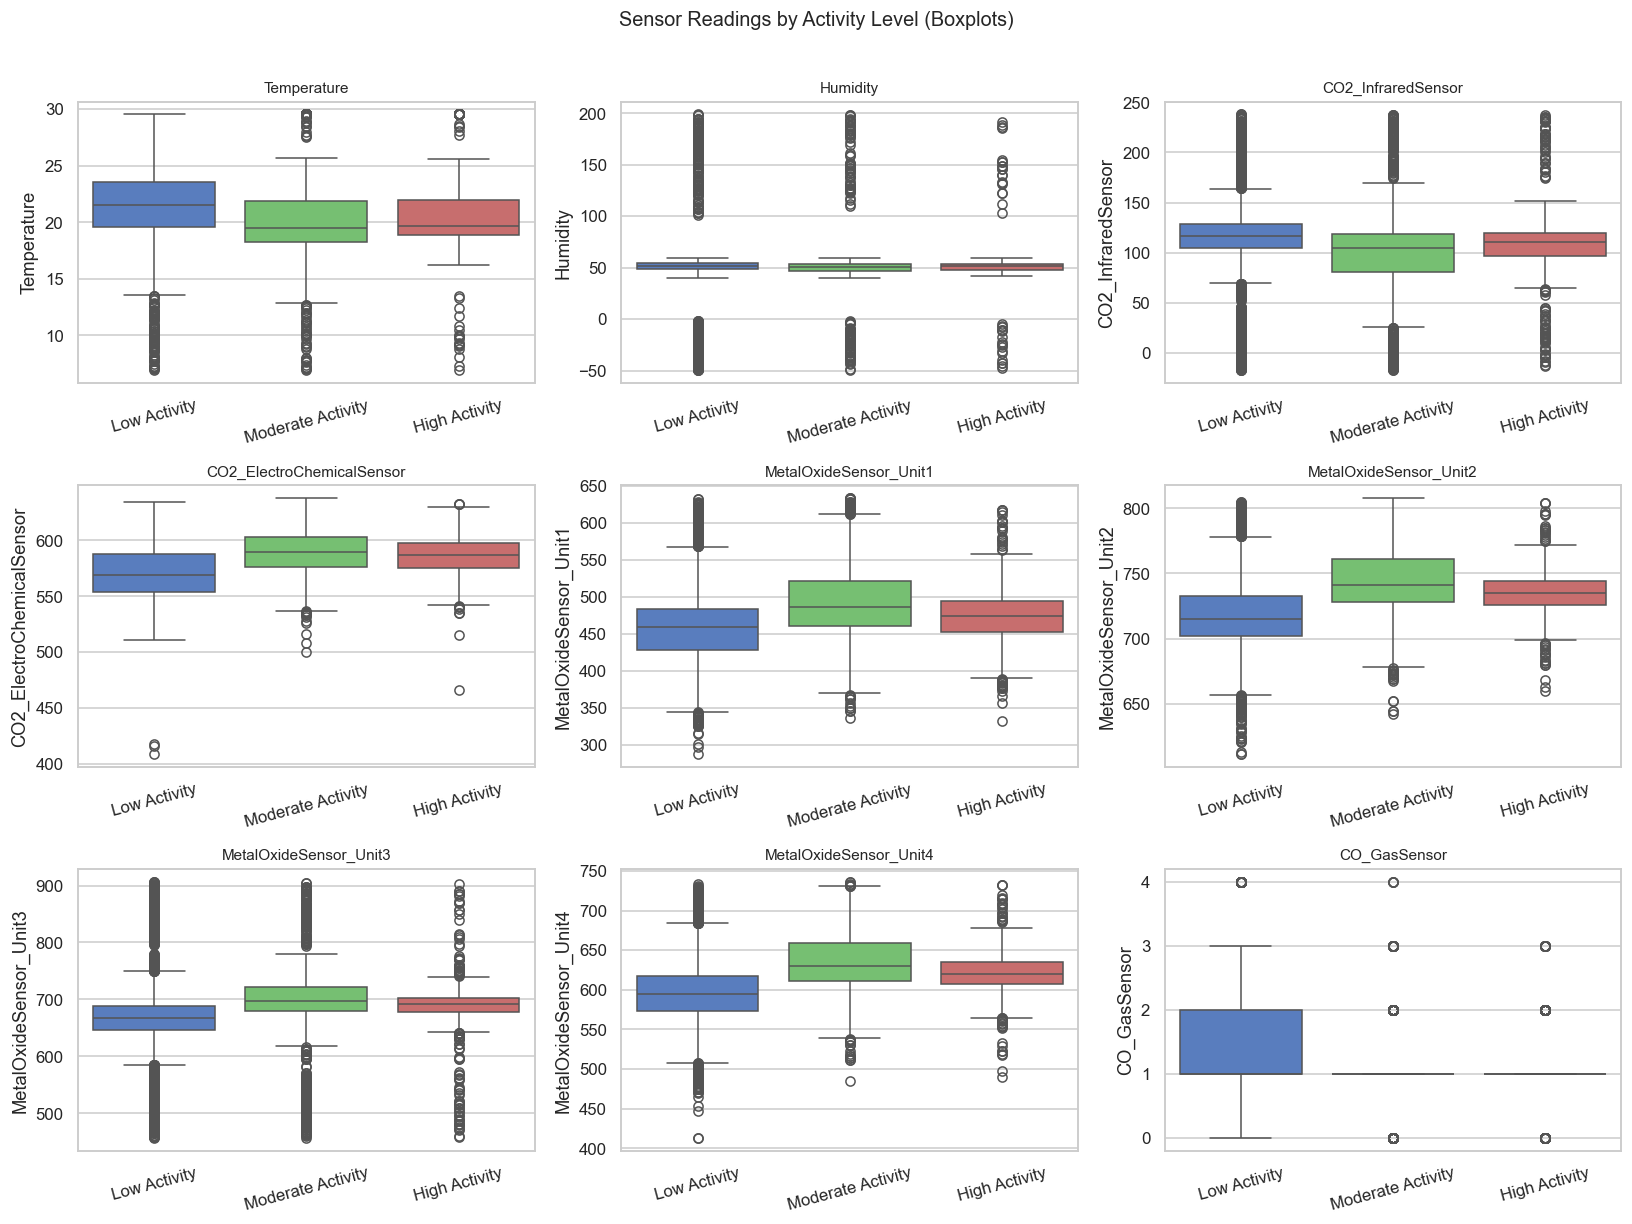

In [10]:
# Boxplots for cleaner class separation view
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
order = ['Low Activity', 'Moderate Activity', 'High Activity']

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Activity Level', y=col, order=order,
                palette=palette, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Sensor Readings by Activity Level (Boxplots)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Conclusion:** The boxplots reveal that `CO2_InfraredSensor` and `CO2_ElectroChemicalSensor` show visible upward trends from Low → Moderate → High activity, consistent with increased respiration/movement producing higher CO2. Metal Oxide sensors show mild but consistent differences. `CO_GasSensor` values are generally lower for High Activity, possibly reflecting sensor-activity interaction patterns. Temperature shows less clear separation after capping. These patterns justify including CO2 and MOS sensor fusion features.

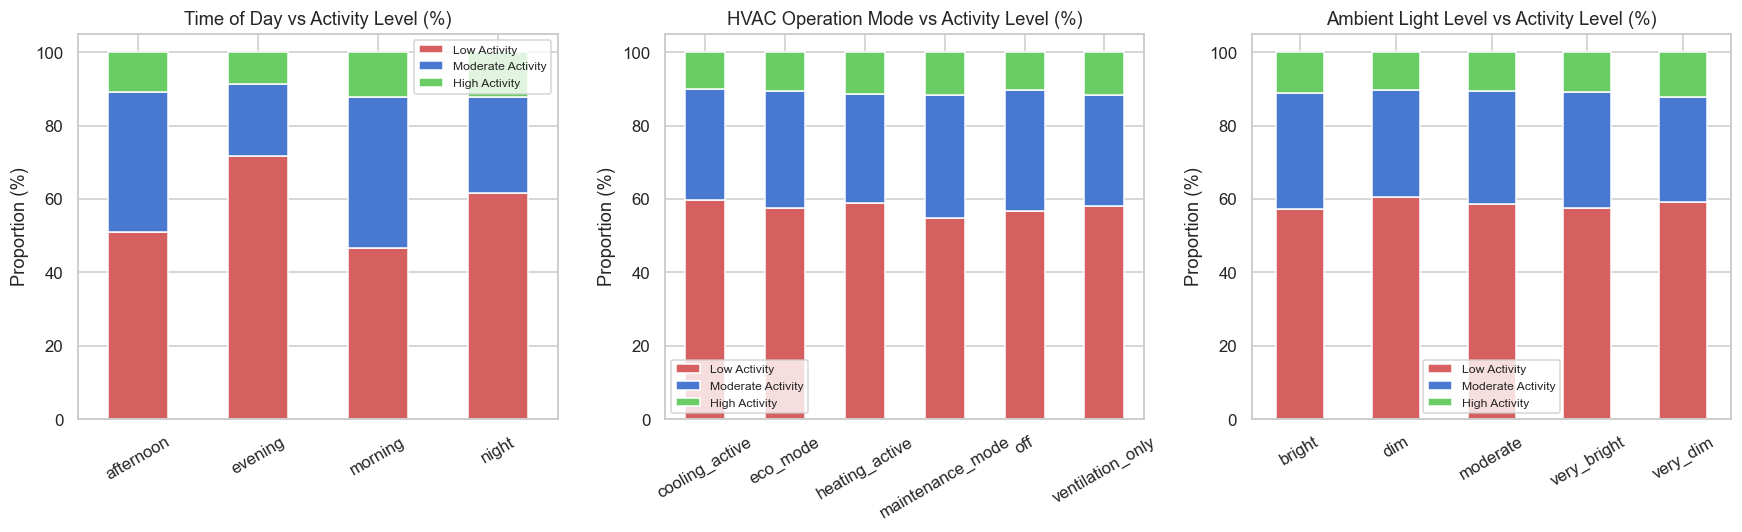

In [11]:
# Categorical vs Target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Activity Level'], normalize='index') * 100
    ct[order].plot(kind='bar', stacked=True, ax=ax,
                   color=['#D65F5F', '#4878CF', '#6ACC65'])
    ax.set_title(f'{col} vs Activity Level (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Proportion (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Conclusion:**
- **Time of Day:** Night hours show the highest proportion of Low Activity (expected sleep). Afternoon and morning periods show relatively more High Activity.
- **HVAC Mode:** Moderate and High Activity are somewhat more common when HVAC is in active modes (cooling, heating), possibly because residents move around and trigger temperature changes.
- **Ambient Light Level:** Brighter environments associate with higher activity levels (residents awake and moving), while `very_dim` correlates strongly with Low Activity (sleeping/resting).

## 6. Correlation Analysis
**Purpose:** Identify multicollinearity between features and understand inter-sensor relationships.

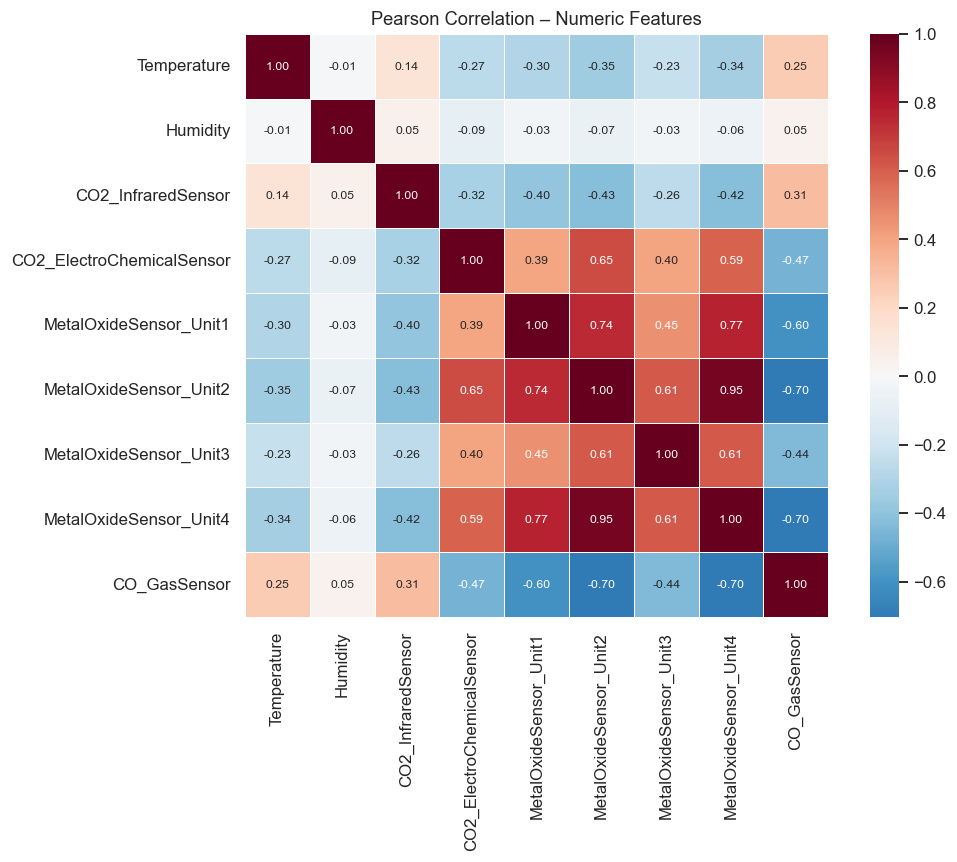

In [12]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pearson Correlation – Numeric Features')
plt.tight_layout()
plt.show()

**Conclusion:** The two CO2 sensors are highly correlated (r ≈ 0.99), as expected since they measure the same gas with different technologies. The four Metal Oxide sensors are also strongly intercorrelated. This high multicollinearity motivates our **sensor fusion features** (`CO2_mean`, `CO2_diff`, `MOS_mean`, `MOS_range`) which condense redundant information and add a *disagreement* signal that raw values alone cannot provide. The Logistic Regression will benefit most from this reduction; tree-based methods can handle collinearity natively but the fusion features still add informative variance.

## 7. Engineered Feature Preview
**Purpose:** Validate that the engineered features add discriminative power before including them in the model.

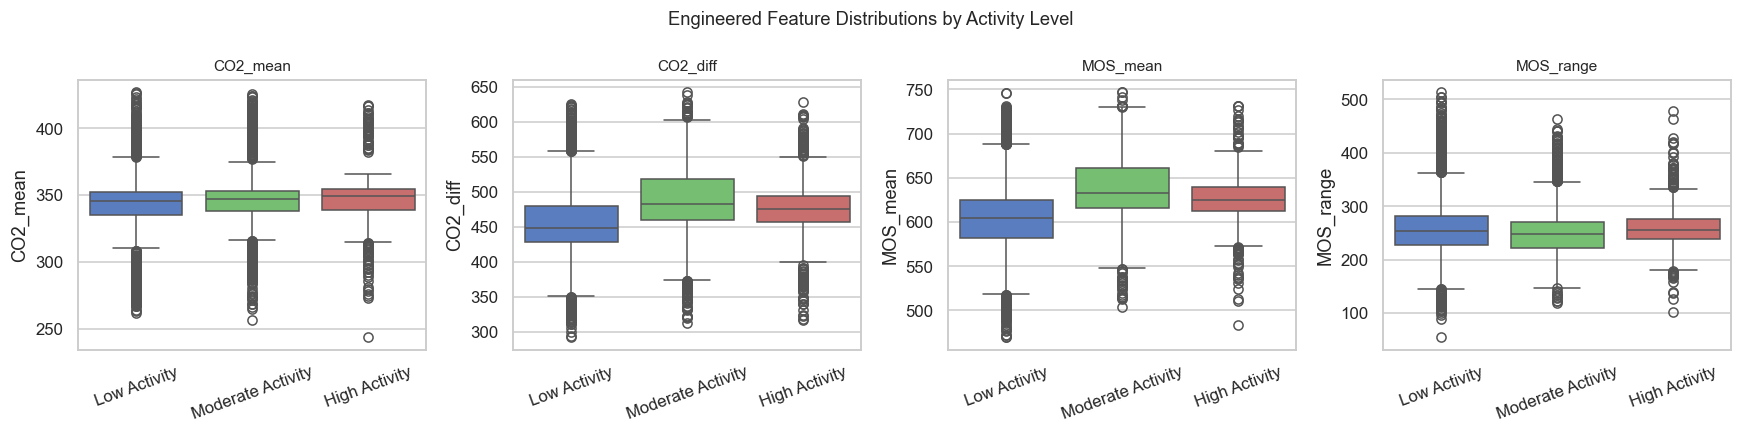

In [13]:
mos_cols = ['MetalOxideSensor_Unit1','MetalOxideSensor_Unit2',
            'MetalOxideSensor_Unit3','MetalOxideSensor_Unit4']

df['CO2_mean']  = df[['CO2_InfraredSensor','CO2_ElectroChemicalSensor']].mean(axis=1)
df['CO2_diff']  = (df['CO2_InfraredSensor'] - df['CO2_ElectroChemicalSensor']).abs()
df['MOS_mean']  = df[mos_cols].mean(axis=1)
df['MOS_range'] = df[mos_cols].max(axis=1) - df[mos_cols].min(axis=1)
df['is_night']  = (df['Time of Day'] == 'night').astype(int)
df['hvac_active'] = (~df['HVAC Operation Mode'].isin({'off','maintenance_mode'})).astype(int)

eng_features = ['CO2_mean', 'CO2_diff', 'MOS_mean', 'MOS_range']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, eng_features):
    sns.boxplot(data=df, x='Activity Level', y=col, order=order,
                palette=palette, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Engineered Feature Distributions by Activity Level', fontsize=12)
plt.tight_layout()
plt.show()

**Justification of Engineered Features:**

| Feature | Rationale |
|---|---|
| `CO2_mean` | Fuses two highly correlated CO2 sensors into one signal; reduces noise via averaging |
| `CO2_diff` | Sensor disagreement — large gaps may signal sensor drift or localised air pockets when resident is active |
| `MOS_mean` | Overall VOC / gas load; elevated when cooking or exerting effort (High Activity) |
| `MOS_range` | Spatial variance between four sensors; higher during active movement |
| `is_night` | Binary flag encoding strongest time-of-day signal (night → Low Activity) |
| `hvac_active` | Active HVAC correlates with resident behaviour (turning on cooling = awake) |

## 8. Session Analysis
**Purpose:** Check whether activity patterns differ systematically across monitoring sessions (to detect session-specific leakage risk).

Number of unique sessions: 38
Sample of per-session activity proportions:


Activity Level,High Activity,Low Activity,Moderate Activity
Session ID,,,
1374,0.110,0.423,0.467
1458,0.051,0.757,0.192
1482,0.168,0.391,0.441
1826,0.085,0.570,0.345
1903,0.062,0.732,0.206
2105,0.191,0.290,0.519
2586,0.089,0.446,0.464
2679,0.160,0.495,0.345
2847,0.137,0.445,0.418


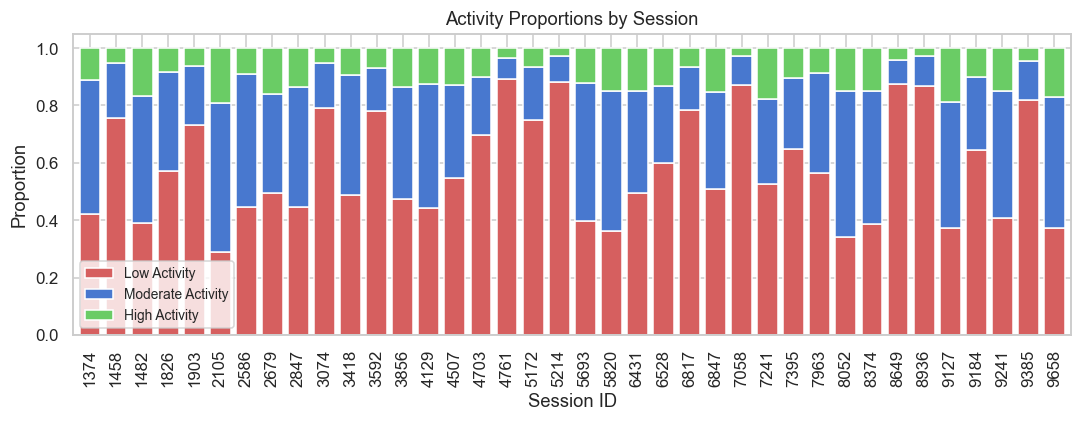

In [14]:
session_counts = df.groupby('Session ID')['Activity Level'].value_counts(normalize=True).unstack(fill_value=0)
print(f'Number of unique sessions: {df["Session ID"].nunique()}')
print('Sample of per-session activity proportions:')
display(session_counts.head(10).round(3))

fig, ax = plt.subplots(figsize=(10, 4))
session_counts[order].plot(kind='bar', stacked=True, ax=ax,
                           color=['#D65F5F', '#4878CF', '#6ACC65'],
                           width=0.8)
ax.set_title('Activity Proportions by Session')
ax.set_xlabel('Session ID')
ax.set_ylabel('Proportion')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion:** Session ID is an administrative grouping identifier. Sessions show varied activity distributions, suggesting they represent different time periods or residents. **Session ID is excluded from the feature set** to prevent the model from learning session-specific patterns that would not generalise.

## 9. Summary of Key EDA Findings

| # | Finding | Action |
|---|---------|--------|
| 1 | `Activity Level` has 6 raw label variants mapping to 3 classes | Normalise all to canonical labels before modelling |
| 2 | `HVAC Operation Mode` has mixed-case duplicates | Lower-case and strip all values |
| 3 | `Temperature` contains physically impossible values (up to 307 °C) | Cap at IQR upper fence (~29.5 °C); treat as sensor fault / synthetic contamination |
| 4 | `Humidity` (19%), `MetalOxideSensor_Unit2` (14%), `Ambient Light Level` (10.5%), `CO_GasSensor` (8.3%) have missing data | Median imputation for numerics; mode imputation for categorical (train-set only) |
| 5 | CO2 sensors are 99% correlated; MOS sensors are highly intercorrelated | Engineer `CO2_mean`, `CO2_diff`, `MOS_mean`, `MOS_range` to reduce redundancy |
| 6 | Class imbalance: Low 58%, Moderate 31%, High 11% | Use macro-averaged F1 as primary evaluation metric; consider recall for High Activity |
| 7 | Ambient Light Level, Time of Day, and CO2 levels are the strongest class discriminators | Prioritise these and their engineered variants in feature importance analysis |
| 8 | Session ID is an identifier, not a sensor feature | Exclude from all model features |

These findings directly inform the preprocessing pipeline and model selection in Task 2.